# Figure 5, all SWE observations
### with all lapse-rate final simulations

created by Cassie Lumbrazo\
last updated: Sept 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# HRRR-AK Lapse-rate Files 
ds_snowpack_hrrrak_lapserate_ppsa, header_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_tram, header_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_lapserate_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_heen, header_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_lapserate_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now
ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

# Met HRRR-AK Lapse-rate Files
ds_snowpack_met_hrrrak_lapserate_ppsa, header_met_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_lapserate_tram, header_met_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_lapserate_tram_WY2023-WY2025_base.smet")
ds_snowpack_met_hrrrak_lapserate_heen, header_met_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_lapserate_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025

/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_20055/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_

### Open Observations

In [5]:
# open observations

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))


# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

In [6]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
hrrrak_lapserate_color = 'tab:orange'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

Cut to just three years each

In [7]:
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-09-01", "2022-09-30"))
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-09-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-09-01", "2025-09-30"))

Previous PPSA only code from before, edit it...

In [8]:
ds_obs_ppsa['hs'] = ds_obs_ppsa['hs'].where(~((ds_obs_ppsa['time'] >= np.datetime64("2024-08-20T00:00")) & (ds_obs_ppsa['time'] <= np.datetime64("2024-10-15T23:59")))) # the spike in 2025

In [9]:
# df created in repo/juneau_field_data/1_create_snowpit_dataframe_WY2025.ipynb
# df.to_csv('/hdd/snow_hydrology/field_data/snow_pit_swe_measurements_WY2025.csv')
df_field_measurements = pd.read_csv('/hdd/snow_hydrology/field_data/snow_pit_swe_measurements_WY2025.csv', index_col=0, parse_dates=True)
df_field_measurements.head()

,snow_depth_cm,snow_depth_in,average_density,swe_mm,swe_m,swe_in
2025-01-23,126,49.606299,334,420.80,0.42080,16.566929
2025-01-28,123,48.425197,317,389.84,0.38984,15.348031
2025-02-12,133,52.362205,334,444.00,0.44400,17.480315
2025-02-16,130,51.181102,334,434.00,0.43400,17.086614
2025-02-20,128,50.393701,306,391.68,0.39168,15.420472


# PPSA Figure first, 

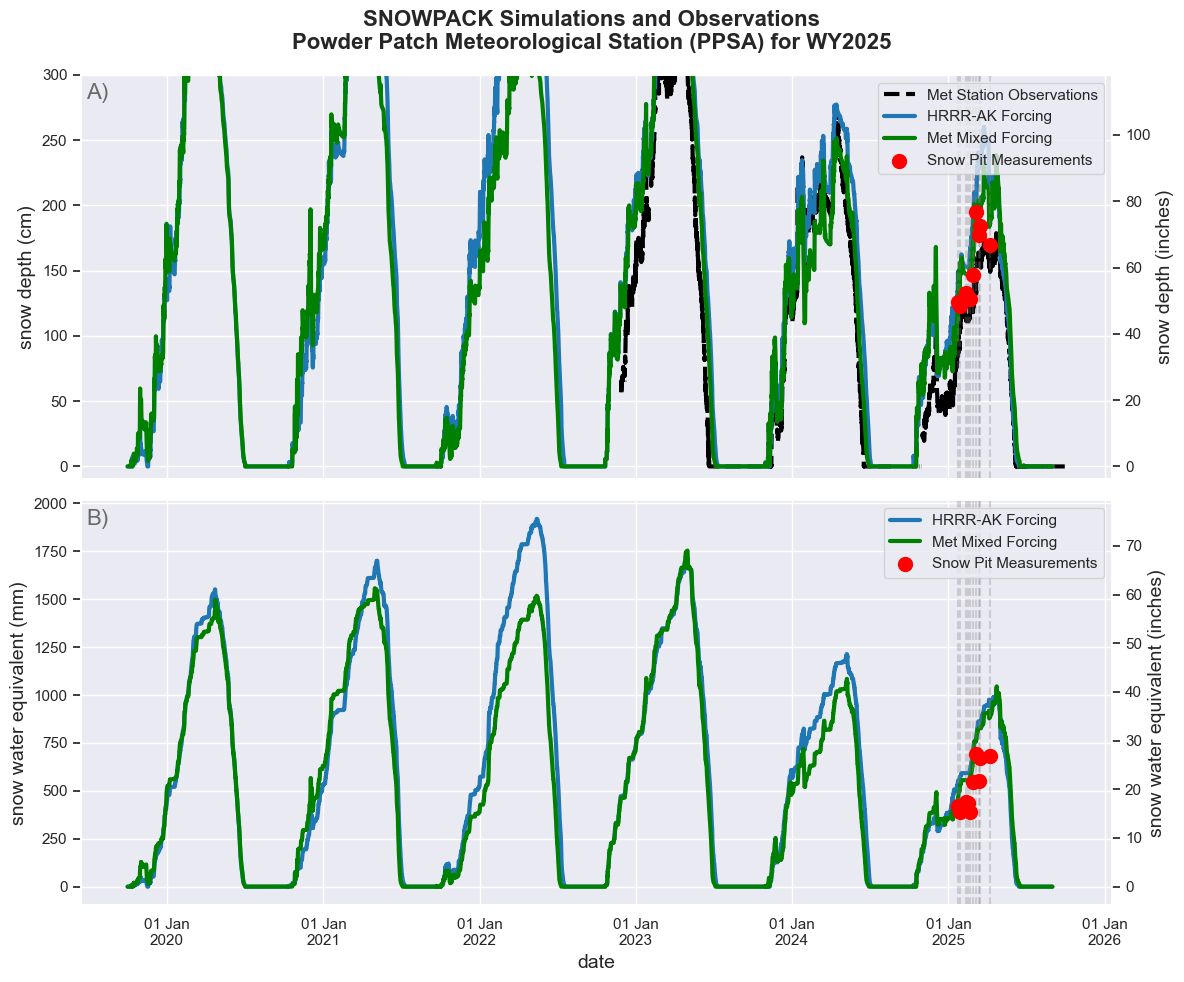

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# FIGURE 4
# PPSA WY2025 Snow Depth + SWE
# Final manuscript forcing configurations only
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True
)

# ============================================================
# A) SNOW DEPTH
# ============================================================

# Continuous observed snow depth
ds_obs_ppsa.hs.plot(
    ax=ax1,
    label='Met Station Observations',
    linewidth=3,
    linestyle='--',
    color='black'
)

# HRRR-AK forcing
# NOTE: this is the lapse-rate-corrected HRRR-AK dataset,
# but we refer to it simply as "HRRR-AK Forcing" in the paper.
ds_snowpack_hrrrak_lapserate_ppsa.HS_mod.plot(
    ax=ax1,
    label='HRRR-AK Forcing',
    linewidth=3,
    color='tab:blue'
)

# Met Station Mixed forcing
# NOTE: HRRR-AK temperature used for gaps is lapse-rate corrected.
ds_snowpack_met_hrrrak_lapserate_ppsa.HS_mod.plot(
    ax=ax1,
    label='Met Mixed Forcing',
    linewidth=3,
    color='green'
)

# Snow pit dates + observed snow depth
for i, date in enumerate(df_field_measurements.index):

    ax1.axvline(
        x=date,
        color='grey',
        linestyle='--',
        alpha=0.3
    )

    ax1.scatter(
        date,
        df_field_measurements.loc[date, 'snow_depth_cm'],
        color='red',
        s=100,
        zorder=5,
        label='Snow Pit Measurements' if i == 0 else None
    )

# Labels
ax1.set_ylabel('snow depth (cm)', fontsize=14)
ax1.set_ylim([-10, 300])
ax1.set_xlabel('')

# Inches on secondary axis
ax1_twin = ax1.twinx()
ax1_twin.set_ylabel('snow depth (inches)', fontsize=14)
ax1_twin.set_ylim(
    ax1.get_ylim()[0] / 2.54,
    ax1.get_ylim()[1] / 2.54
)
ax1_twin.grid(False)

ax1.legend(loc='upper right')

# Panel label
ax1.text(
    0.005, 0.98,
    'A)',
    transform=ax1.transAxes,
    fontsize=16,
    color='dimgrey',
    va='top'
)


# ============================================================
# B) SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa.SWE.plot(
    ax=ax2,
    label='HRRR-AK Forcing',
    linewidth=3,
    color='tab:blue'
)

# Met Station Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa.SWE.plot(
    ax=ax2,
    label='Met Mixed Forcing',
    linewidth=3,
    color='green'
)

# Snow pit dates
for date in df_field_measurements.index:
    ax2.axvline(
        x=date,
        color='grey',
        linestyle='--',
        alpha=0.3
    )

# Observed SWE from snow pits
ax2.scatter(
    df_field_measurements.index,
    df_field_measurements['swe_mm'],
    color='red',
    s=100,
    zorder=5,
    label='Snow Pit Measurements'
)

# Labels
ax2.set_ylabel('snow water equivalent (mm)', fontsize=14)
ax2.set_xlabel('date', fontsize=14)

# Inches on secondary axis
ax2_twin = ax2.twinx()
ax2_twin.set_ylabel('snow water equivalent (inches)', fontsize=14)
ax2_twin.set_ylim(
    ax2.get_ylim()[0] * 0.0393701,
    ax2.get_ylim()[1] * 0.0393701
)
ax2_twin.grid(False)

ax2.legend(loc='upper right')

# Panel label
ax2.text(
    0.005, 0.98,
    'B)',
    transform=ax2.transAxes,
    fontsize=16,
    color='dimgrey',
    va='top'
)


# ============================================================
# FORMATTING
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observations\n'
    'Powder Patch Meteorological Station (PPSA) for WY2025',
    fontweight='bold',
    fontsize=16
)

# Format dates
ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b\n%Y')
)

plt.tight_layout()
plt.show()

# SWE at HEEN

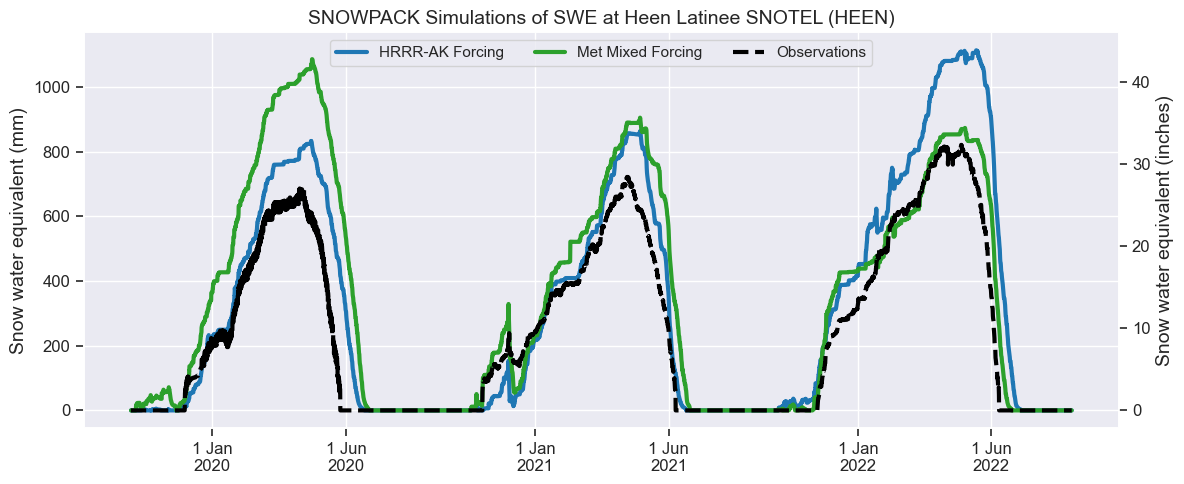

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Figure formatting
# ============================================================

title_fontsize = 14
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11

major_tick_length = 6
major_tick_width = 1.2

line_width = 3


# ============================================================
# HEEN SWE: WY2020-WY2022
# ============================================================

heen_start = "2019-09-01"
heen_end   = "2022-08-30"


# ------------------------------------------------------------
# Subset observations
# ------------------------------------------------------------

ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)


# ------------------------------------------------------------
# HRRR-AK lapse-rate corrected simulation
# ------------------------------------------------------------

ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)


# ------------------------------------------------------------
# Mixed Met + HRRR-AK lapse-rate corrected simulation
# ------------------------------------------------------------

ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))


# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)


# Mixed Met forcing
ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="tab:green"
)


# Observations
# Convert observed SWE to mm
(ds_obs_heen_plot.swe * 10).plot(
    ax=ax,
    label="Observations",
    linewidth=line_width,
    color="black", 
    linestyle="--",
)


# ============================================================
# Titles and axis labels
# ============================================================

ax.set_title(
    "SNOWPACK Simulations of SWE at Heen Latinee SNOTEL (HEEN)",
    fontsize=title_fontsize
)

ax.set_ylabel(
    "Snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax.set_xlabel(
    # "Date",
    "",
    fontsize=axis_label_fontsize
)


# ============================================================
# X-axis formatting
# ============================================================

ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 6])
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%-d %b\n%Y")
)

ax.tick_params(
    axis="x",
    which="major",
    bottom=True,
    labelbottom=True,
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width,
)

for label in ax.get_xticklabels():
    label.set_visible(True)


# ============================================================
# Left y-axis formatting
# ============================================================

ax.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width,
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    fontsize=legend_fontsize,
    loc="upper center",
    frameon=True,
    ncol=3,
)


# ============================================================
# Second y-axis in inches
# ============================================================

ax2 = ax.twinx()

ax2.set_ylabel(
    "Snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

# Synchronize inches axis with mm axis
ymin, ymax = ax.get_ylim()

ax2.set_ylim(
    ymin * 0.0393701,
    ymax * 0.0393701
)

ax2.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width,
)

ax2.grid(False)


# ============================================================
# Final layout
# ============================================================

plt.tight_layout()
plt.show()

# New Figure 5

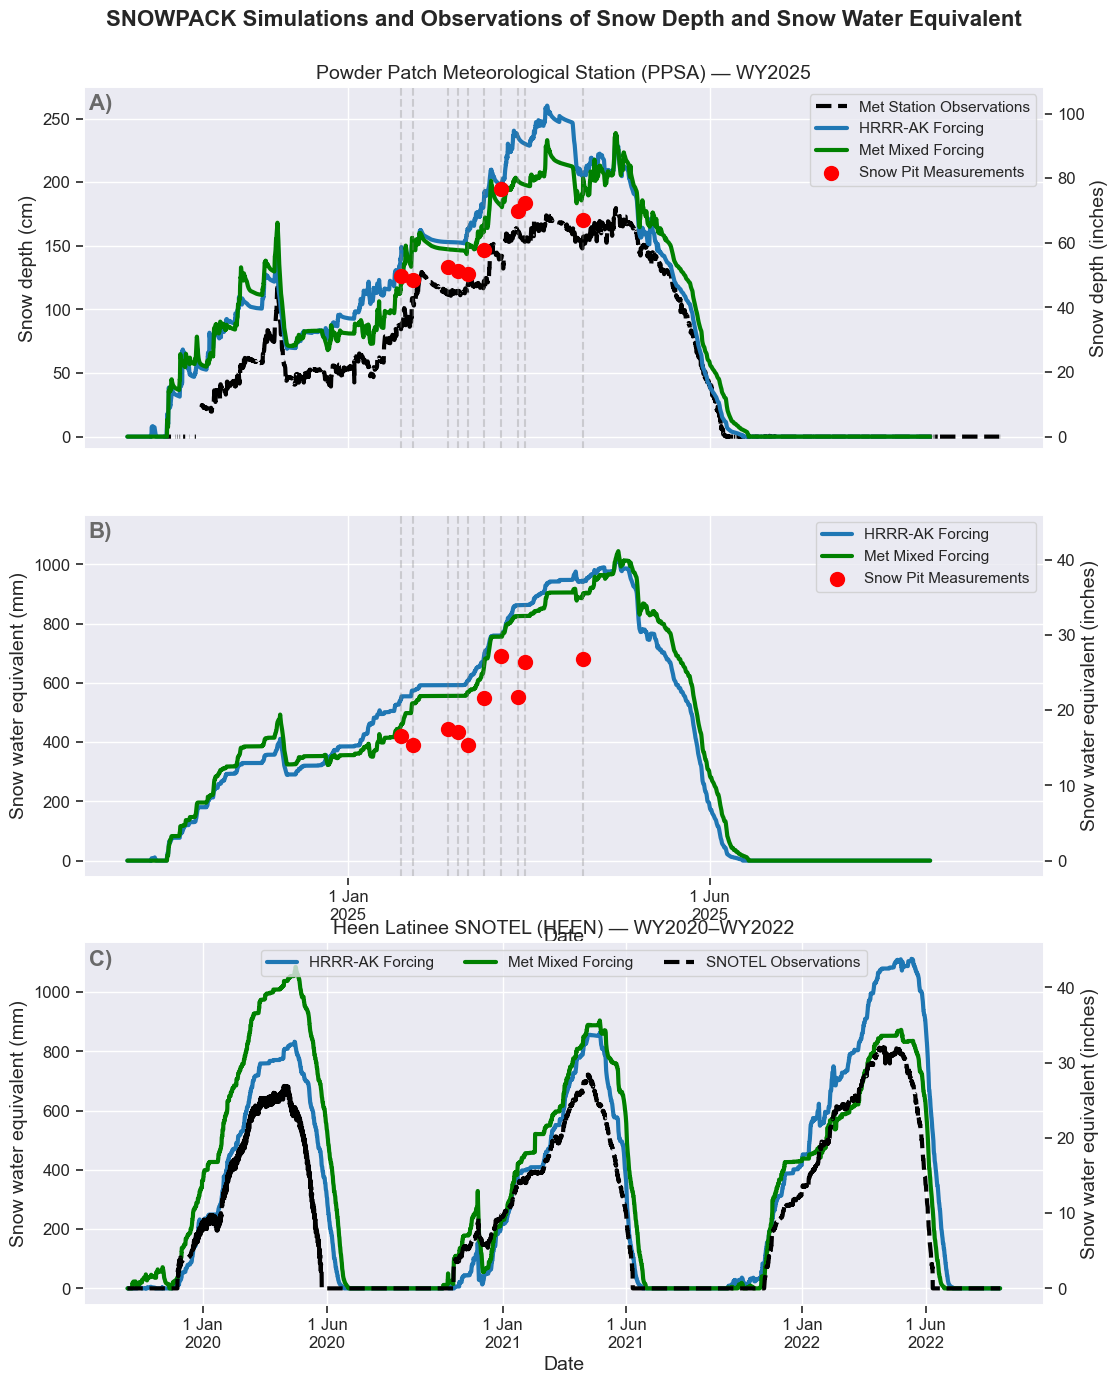

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# FIGURE 4
# SNOWPACK Simulations and Observations of Snow Depth and SWE
#
# A) PPSA snow depth, WY2025
# B) PPSA SWE, WY2025
# C) HEEN SWE, WY2020-WY2022
# ============================================================


# ============================================================
# MANUSCRIPT FORMATTING
# ============================================================

figure_title_fontsize = 16
panel_title_fontsize = 14
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11
panel_label_fontsize = 16

line_width = 3
scatter_size = 100

major_tick_length = 6
major_tick_width = 1.2


# ============================================================
# DATE RANGES
# ============================================================

# PPSA -> WY2025
ppsa_start = "2024-10-01"
ppsa_end   = "2025-09-30"

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"


# ============================================================
# SUBSET PPSA DATA TO WY2025
# ============================================================

# Observations
ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(ppsa_start, ppsa_end)
)

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_met_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Snow-pit measurements within WY2025
df_field_measurements_plot = df_field_measurements.loc[
    (df_field_measurements.index >= ppsa_start) &
    (df_field_measurements.index <= ppsa_end)
]


# ============================================================
# SUBSET HEEN DATA TO WY2020-WY2022
# ============================================================

# Observations
ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig = plt.figure(figsize=(12, 14))

gs = fig.add_gridspec(
    3, 1,
    height_ratios=[1, 1, 1],
    hspace=0.18
)

# A and B share x-axis
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# B and C share SWE y-axis
# C retains its own independent x-axis
ax3 = fig.add_subplot(gs[2], sharey=ax2)


# ============================================================
# A) PPSA SNOW DEPTH
# ============================================================

# Continuous observed snow depth
ds_obs_ppsa_plot.hs.plot(
    ax=ax1,
    label="Met Station Observations",
    linewidth=line_width,
    linestyle="--",
    color="black"
)

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa_plot.HS_mod.plot(
    ax=ax1,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa_plot.HS_mod.plot(
    ax=ax1,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Snow-pit dates + observed snow depth
for i, date in enumerate(df_field_measurements_plot.index):

    ax1.axvline(
        x=date,
        color="grey",
        linestyle="--",
        alpha=0.3
    )

    ax1.scatter(
        date,
        df_field_measurements_plot.loc[date, "snow_depth_cm"],
        color="red",
        s=scatter_size,
        zorder=5,
        label="Snow Pit Measurements" if i == 0 else None
    )


# ------------------------------------------------------------
# Panel A formatting
# ------------------------------------------------------------

ax1.set_title(
    "Powder Patch Meteorological Station (PPSA) — WY2025",
    fontsize=panel_title_fontsize
)

ax1.set_ylabel(
    "Snow depth (cm)",
    fontsize=axis_label_fontsize
)

ax1.set_xlabel("")

ax1.set_ylim([-10, 275])

ax1.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1.legend(
    loc="upper right",
    fontsize=legend_fontsize,
    frameon=True
)

# Panel label
ax1.text(
    0.005, 0.98,
    "A)",
    transform=ax1.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top",
    fontweight="bold"
)


# ------------------------------------------------------------
# Panel A secondary y-axis: inches
# ------------------------------------------------------------

ax1_twin = ax1.twinx()

ax1_twin.set_ylabel(
    "Snow depth (inches)",
    fontsize=axis_label_fontsize
)

ax1_twin.set_ylim(
    ax1.get_ylim()[0] / 2.54,
    ax1.get_ylim()[1] / 2.54
)

ax1_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1_twin.grid(False)


# ============================================================
# B) PPSA SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax2,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax2,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Snow-pit dates
for date in df_field_measurements_plot.index:

    ax2.axvline(
        x=date,
        color="grey",
        linestyle="--",
        alpha=0.3
    )

# Observed SWE from snow pits
ax2.scatter(
    df_field_measurements_plot.index,
    df_field_measurements_plot["swe_mm"],
    color="red",
    s=scatter_size,
    zorder=5,
    label="Snow Pit Measurements"
)


# ------------------------------------------------------------
# Panel B formatting
# ------------------------------------------------------------

ax2.set_ylabel(
    "Snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax2.set_xlabel(
    "Date",
    fontsize=axis_label_fontsize
)

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2.legend(
    loc="upper right",
    fontsize=legend_fontsize,
    frameon=True
)

# Panel label
ax2.text(
    0.005, 0.98,
    "B)",
    transform=ax2.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top",
    fontweight="bold"
)


# ------------------------------------------------------------
# Panel B secondary y-axis: inches
# ------------------------------------------------------------

ax2_twin = ax2.twinx()

ax2_twin.set_ylabel(
    "Snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax2_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2_twin.grid(False)


# ============================================================
# C) HEEN SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax3,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax3,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Continuous HEEN SWE observations
# Convert observed SWE to mm
(ds_obs_heen_plot.swe * 10).plot(
    ax=ax3,
    label="SNOTEL Observations",
    linewidth=line_width,
    linestyle="--",
    color="black"
)


# ------------------------------------------------------------
# Panel C formatting
# ------------------------------------------------------------

ax3.set_title(
    "Heen Latinee SNOTEL (HEEN) — WY2020–WY2022",
    fontsize=panel_title_fontsize
)

ax3.set_ylabel(
    "Snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax3.set_xlabel(
    "Date",
    fontsize=axis_label_fontsize
)

ax3.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax3.legend(
    loc="upper center",
    fontsize=legend_fontsize,
    frameon=True,
    ncol=3
)

# Panel label
ax3.text(
    0.005, 0.98,
    "C)",
    transform=ax3.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top",
    fontweight="bold"
)


# ------------------------------------------------------------
# Panel C secondary y-axis: inches
# ------------------------------------------------------------

ax3_twin = ax3.twinx()

ax3_twin.set_ylabel(
    "Snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax3_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax3_twin.grid(False)


# ============================================================
# SYNCHRONIZE SWE AXES
# Panels B and C share their primary y-axis
# ============================================================

# Because ax2 and ax3 use sharey=ax2, matplotlib gives them
# the same SWE limits. Now synchronize both inches axes to
# those shared mm limits.

swe_ymin, swe_ymax = ax2.get_ylim()

ax2_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)

ax3_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)


# ============================================================
# X-AXIS FORMATTING
# ============================================================

# ------------------------------------------------------------
# PPSA panels A + B
# Shared WY2025 x-axis
# ------------------------------------------------------------

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 6])
)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter("%-d %b\n%Y")
)

ax2.tick_params(
    axis="x",
    which="major",
    bottom=True,
    labelbottom=True,
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

# Do not repeat date labels on Panel A
plt.setp(
    ax1.get_xticklabels(),
    visible=False
)

ax1.tick_params(
    axis="x",
    which="major",
    labelbottom=False
)


# ------------------------------------------------------------
# HEEN Panel C
# Independent WY2020-WY2022 x-axis
# ------------------------------------------------------------

ax3.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 6])
)

ax3.xaxis.set_major_formatter(
    mdates.DateFormatter("%-d %b\n%Y")
)

ax3.tick_params(
    axis="x",
    which="major",
    bottom=True,
    labelbottom=True,
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

for label in ax3.get_xticklabels():
    label.set_visible(True)


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "SNOWPACK Simulations and Observations of Snow Depth and "
    "Snow Water Equivalent",
    fontsize=figure_title_fontsize,
    fontweight="bold",
    y=0.995
)


# ============================================================
# FINAL LAYOUT
# ============================================================

fig.subplots_adjust(
    top=0.94,
    bottom=0.07,
    left=0.10,
    right=0.90,
    hspace=0.22
)


plt.show()

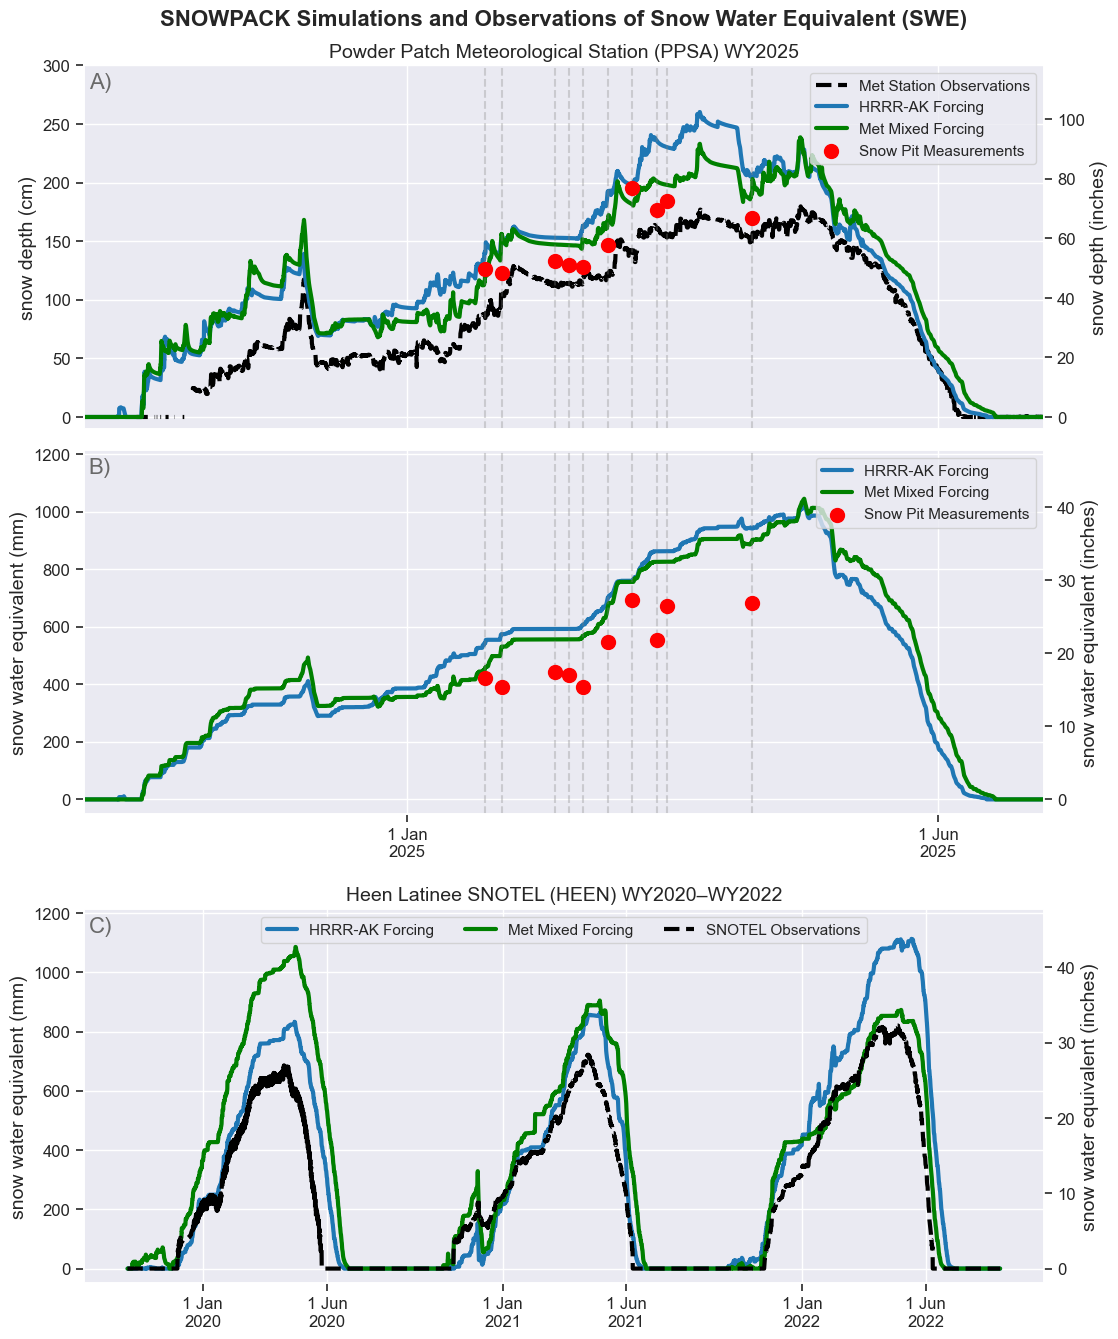

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


# ============================================================
# FIGURE 4
# SNOWPACK Simulations and Observations of snow depth and SWE
#
# A) PPSA snow depth, WY2025
# B) PPSA SWE, WY2025
# C) HEEN SWE, WY2020-WY2022
# ============================================================


# ============================================================
# MANUSCRIPT FORMATTING
# ============================================================

figure_title_fontsize = 16
panel_title_fontsize = 14
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11
panel_label_fontsize = 16

line_width = 3
scatter_size = 100

major_tick_length = 6
major_tick_width = 1.2


# ============================================================
# DATE RANGES
# ============================================================

# PPSA -> WY2025
# Plot only through 1 July to focus on the snow season
ppsa_start = "2024-10-01"
ppsa_end   = "2025-07-01"

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end   = "2022-08-30"


# ============================================================
# SUBSET PPSA DATA
# ============================================================

# Observations
ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(ppsa_start, ppsa_end)
)

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_met_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Snow-pit measurements within plotting period
df_field_measurements_plot = df_field_measurements.loc[
    (df_field_measurements.index >= ppsa_start) &
    (df_field_measurements.index <= ppsa_end)
]


# ============================================================
# SUBSET HEEN DATA
# ============================================================

# Observations
ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)


# ============================================================
# CREATE FIGURE
#
# Nested GridSpec lets A and B sit closer together,
# while preserving more space between B and C.
# ============================================================

fig = plt.figure(figsize=(12, 14))

outer_gs = fig.add_gridspec(
    2, 1,
    height_ratios=[2, 1],
    hspace=0.17
)

# Panels A and B grouped closely together
upper_gs = outer_gs[0].subgridspec(
    2, 1,
    hspace=0.06
)

ax1 = fig.add_subplot(upper_gs[0])
ax2 = fig.add_subplot(upper_gs[1], sharex=ax1)

# Panel C gets its own x-axis but shares SWE y-axis with B
ax3 = fig.add_subplot(
    outer_gs[1],
    sharey=ax2
)


# ============================================================
# A) PPSA SNOW DEPTH
# ============================================================

# Continuous observed snow depth
ds_obs_ppsa_plot.hs.plot(
    ax=ax1,
    label="Met Station Observations",
    linewidth=line_width,
    linestyle="--",
    color="black"
)

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa_plot.HS_mod.plot(
    ax=ax1,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa_plot.HS_mod.plot(
    ax=ax1,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Snow-pit dates + observed snow depth
for i, date in enumerate(df_field_measurements_plot.index):

    ax1.axvline(
        x=date,
        color="grey",
        linestyle="--",
        alpha=0.3
    )

    ax1.scatter(
        date,
        df_field_measurements_plot.loc[date, "snow_depth_cm"],
        color="red",
        s=scatter_size,
        zorder=5,
        label="Snow Pit Measurements" if i == 0 else None
    )


# ------------------------------------------------------------
# Panel A formatting
# ------------------------------------------------------------

ax1.set_title(
    "Powder Patch Meteorological Station (PPSA) WY2025",
    fontsize=panel_title_fontsize
)

ax1.set_ylabel(
    "snow depth (cm)",
    fontsize=axis_label_fontsize
)

ax1.set_xlabel("")

ax1.set_ylim([-10, 300])

ax1.set_xlim(
    mdates.datestr2num(ppsa_start),
    mdates.datestr2num(ppsa_end)
)

ax1.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1.legend(
    loc="upper right",
    fontsize=legend_fontsize,
    frameon=True
)

# Panel label
ax1.text(
    0.005, 0.98,
    "A)",
    transform=ax1.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel A secondary y-axis: inches
# ------------------------------------------------------------

ax1_twin = ax1.twinx()

ax1_twin.set_ylabel(
    "snow depth (inches)",
    fontsize=axis_label_fontsize
)

ax1_twin.set_ylim(
    ax1.get_ylim()[0] / 2.54,
    ax1.get_ylim()[1] / 2.54
)

ax1_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1_twin.grid(False)


# ============================================================
# B) PPSA SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax2,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax2,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Snow-pit dates
for date in df_field_measurements_plot.index:

    ax2.axvline(
        x=date,
        color="grey",
        linestyle="--",
        alpha=0.3
    )

# Observed SWE from snow pits
ax2.scatter(
    df_field_measurements_plot.index,
    df_field_measurements_plot["swe_mm"],
    color="red",
    s=scatter_size,
    zorder=5,
    label="Snow Pit Measurements"
)


# ------------------------------------------------------------
# Panel B formatting
# ------------------------------------------------------------

ax2.set_ylabel(
    "snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

# Remove x-axis title
ax2.set_xlabel("")

ax2.set_xlim(
    mdates.datestr2num(ppsa_start),
    mdates.datestr2num(ppsa_end)
)

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2.legend(
    loc="upper right",
    fontsize=legend_fontsize,
    frameon=True
)

# Panel label
ax2.text(
    0.005, 0.98,
    "B)",
    transform=ax2.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel B secondary y-axis: inches
# ------------------------------------------------------------

ax2_twin = ax2.twinx()

ax2_twin.set_ylabel(
    "snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax2_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2_twin.grid(False)


# ============================================================
# C) HEEN SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax3,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax3,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Continuous HEEN SWE observations
# Convert observed SWE to mm
(ds_obs_heen_plot.swe * 10).plot(
    ax=ax3,
    label="SNOTEL Observations",
    linewidth=line_width,
    linestyle="--",
    color="black"
)


# ------------------------------------------------------------
# Panel C formatting
# ------------------------------------------------------------

ax3.set_title(
    "Heen Latinee SNOTEL (HEEN) WY2020–WY2022",
    fontsize=panel_title_fontsize
)

ax3.set_ylabel(
    "snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

# Remove x-axis title
ax3.set_xlabel("")

ax3.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax3.legend(
    loc="upper center",
    fontsize=legend_fontsize,
    frameon=True,
    ncol=3
)

# Panel label
ax3.text(
    0.005, 0.98,
    "C)",
    transform=ax3.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel C secondary y-axis: inches
# ------------------------------------------------------------

ax3_twin = ax3.twinx()

ax3_twin.set_ylabel(
    "snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax3_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax3_twin.grid(False)


# ============================================================
# SYNCHRONIZE SWE Y-AXES
# Panels B and C share the same primary SWE y-axis.
#
# Add 100 mm of headroom above the largest SWE value.
# ============================================================

swe_max = max(
    float(ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.max()),
    float(ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.max()),
    float(df_field_measurements_plot["swe_mm"].max()),
    float(ds_snowpack_hrrrak_lapserate_heen_plot.SWE.max()),
    float(ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.max()),
    float((ds_obs_heen_plot.swe * 10).max())
)

swe_ymin = -50
swe_ymax = swe_max + 100

ax2.set_ylim(
    swe_ymin,
    swe_ymax
)

# ax3 automatically receives the same limits because sharey=ax2


# ------------------------------------------------------------
# Synchronize secondary SWE axes in inches
# ------------------------------------------------------------

ax2_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)

ax3_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)


# ============================================================
# X-AXIS FORMATTING
# ============================================================

# ------------------------------------------------------------
# PPSA Panels A + B
# ------------------------------------------------------------

# Only show labels on Panel B
plt.setp(
    ax1.get_xticklabels(),
    visible=False
)

ax1.tick_params(
    axis="x",
    labelbottom=False
)

# Jan and Jun ticks
ax2.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 6])
)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter("%-d %b\n%Y")
)

ax2.tick_params(
    axis="x",
    which="major",
    bottom=True,
    labelbottom=True,
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)


# ------------------------------------------------------------
# HEEN Panel C
# Independent WY2020-WY2022 x-axis
# ------------------------------------------------------------

ax3.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 6])
)

ax3.xaxis.set_major_formatter(
    mdates.DateFormatter("%-d %b\n%Y")
)

ax3.tick_params(
    axis="x",
    which="major",
    bottom=True,
    labelbottom=True,
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "SNOWPACK Simulations and Observations of "
    "Snow Water Equivalent (SWE)",
    fontsize=figure_title_fontsize,
    fontweight="bold",
    y=0.97
)


# ============================================================
# FINAL LAYOUT
# ============================================================

fig.subplots_adjust(
    top=0.93,
    bottom=0.06,
    left=0.10,
    right=0.90
)


plt.show()

Now, without panel a)

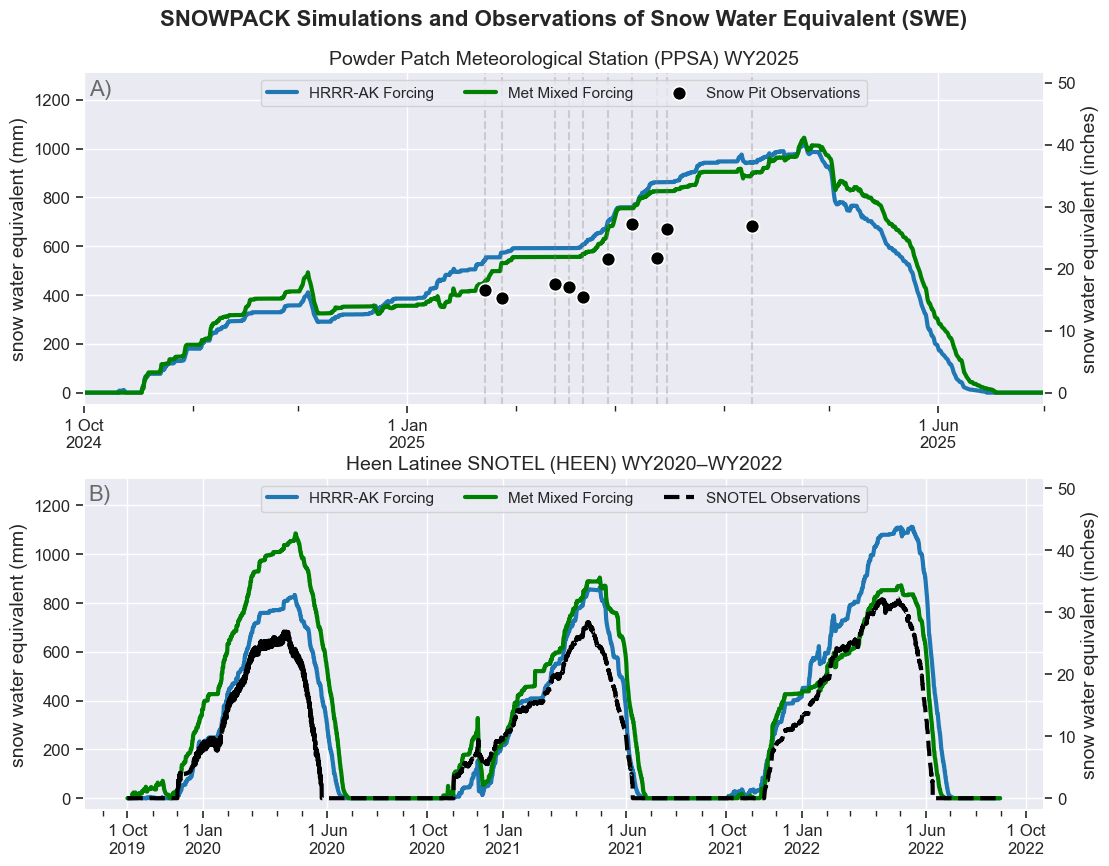

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


# ============================================================
# FIGURE 4
# SNOWPACK Simulations and Observations of SWE
#
# A) PPSA SWE, WY2025
# B) HEEN SWE, WY2020-WY2022
# ============================================================


# ============================================================
# MANUSCRIPT FORMATTING
# ============================================================

figure_title_fontsize = 16
panel_title_fontsize = 14
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11
panel_label_fontsize = 16

line_width = 3
scatter_size = 100

major_tick_length = 6
major_tick_width = 1.2

minor_tick_length = 4
minor_tick_width = 1.0


# ============================================================
# DATE RANGES
# ============================================================

# PPSA -> WY2025
ppsa_start = "2024-10-01"
ppsa_end = "2025-07-01"

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end = "2022-08-30"


# ============================================================
# SUBSET PPSA DATA
# ============================================================

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_met_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Snow-pit measurements within plotting period
df_field_measurements_plot = df_field_measurements.loc[
    (df_field_measurements.index >= ppsa_start) &
    (df_field_measurements.index <= ppsa_end)
]


# ============================================================
# SUBSET HEEN DATA
# ============================================================

# Observations
ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 9),
    sharey=True
)

plt.subplots_adjust(
    hspace=0.18
)


# ============================================================
# A) PPSA SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax1,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax1,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Snow-pit dates
for date in df_field_measurements_plot.index:
    ax1.axvline(
        x=date,
        color="grey",
        linestyle="--",
        alpha=0.3
    )

# Observed SWE from snow pits
ax1.scatter(
    df_field_measurements_plot.index,
    df_field_measurements_plot["swe_mm"],
    color="black",
    edgecolors="white",
    linewidths=1.2,
    s=scatter_size,
    zorder=3,
    label="Snow Pit Observations"
)


# ------------------------------------------------------------
# Panel A formatting
# ------------------------------------------------------------

ax1.set_title(
    "Powder Patch Meteorological Station (PPSA) WY2025",
    fontsize=panel_title_fontsize
)

ax1.set_ylabel(
    "snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax1.set_xlabel("")

ax1.set_xlim(
    mdates.datestr2num(ppsa_start),
    mdates.datestr2num(ppsa_end)
)

ax1.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1.legend(
    loc="upper center",
    fontsize=legend_fontsize,
    frameon=True,
    ncol=3
)

# Panel label
ax1.text(
    0.005, 0.98,
    "A)",
    transform=ax1.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel A secondary y-axis: inches
# ------------------------------------------------------------

ax1_twin = ax1.twinx()

ax1_twin.set_ylabel(
    "snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax1_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1_twin.grid(False)


# ============================================================
# B) HEEN SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax2,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax2,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Continuous HEEN SWE observations
# Convert observed SWE to mm
(ds_obs_heen_plot.swe * 10).plot(
    ax=ax2,
    label="SNOTEL Observations",
    linewidth=line_width,
    linestyle="--",
    color="black"
)


# ------------------------------------------------------------
# Panel B formatting
# ------------------------------------------------------------

ax2.set_title(
    "Heen Latinee SNOTEL (HEEN) WY2020–WY2022",
    fontsize=panel_title_fontsize
)

ax2.set_ylabel(
    "snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax2.set_xlabel("")

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2.legend(
    loc="upper center",
    fontsize=legend_fontsize,
    frameon=True,
    ncol=3
)

# Panel label
ax2.text(
    0.005, 0.98,
    "B)",
    transform=ax2.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel B secondary y-axis: inches
# ------------------------------------------------------------

ax2_twin = ax2.twinx()

ax2_twin.set_ylabel(
    "snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax2_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2_twin.grid(False)


# ============================================================
# SYNCHRONIZE SWE Y-AXES
# ============================================================

swe_max = max(
    float(ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.max()),
    float(ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.max()),
    float(df_field_measurements_plot["swe_mm"].max()),
    float(ds_snowpack_hrrrak_lapserate_heen_plot.SWE.max()),
    float(ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.max()),
    float((ds_obs_heen_plot.swe * 10).max())
)

swe_ymin = -50
swe_ymax = swe_max + 200

ax1.set_ylim(
    swe_ymin,
    swe_ymax
)

# ax2 automatically shares the same limits because sharey=True


# ------------------------------------------------------------
# Synchronize secondary SWE axes in inches
# ------------------------------------------------------------

ax1_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)

ax2_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)


# ============================================================
# X-AXIS FORMATTING
# ============================================================

for ax in [ax1, ax2]:

    # Major ticks:
    # Label only October 1, January 1, and June 1
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(bymonth=[10, 1, 6], bymonthday=1)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%-d %b\n%Y")
    )

    # Minor ticks:
    # Add an unlabeled tick on the first day of every month
    ax.xaxis.set_minor_locator(
        mdates.MonthLocator(bymonthday=1)
    )

    # Major tick formatting
    ax.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width
    )

    # Minor monthly tick formatting
    ax.tick_params(
        axis="x",
        which="minor",
        bottom=True,
        labelbottom=False,
        length=minor_tick_length,
        width=minor_tick_width
    )


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "SNOWPACK Simulations and Observations of "
    "Snow Water Equivalent (SWE)",
    fontsize=figure_title_fontsize,
    fontweight="bold",
    y=0.97
)


# ============================================================
# FINAL LAYOUT
# ============================================================

fig.subplots_adjust(
    top=0.90,
    bottom=0.08,
    left=0.10,
    right=0.90,
    hspace=0.22
)


# ============================================================
# SAVE FIGURE
# ============================================================

# High-resolution PNG
plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure5.png",
    dpi=300,
    bbox_inches="tight"
)

# Vector PDF for journal submission
plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure5.pdf",
    bbox_inches="tight"
)

plt.show()

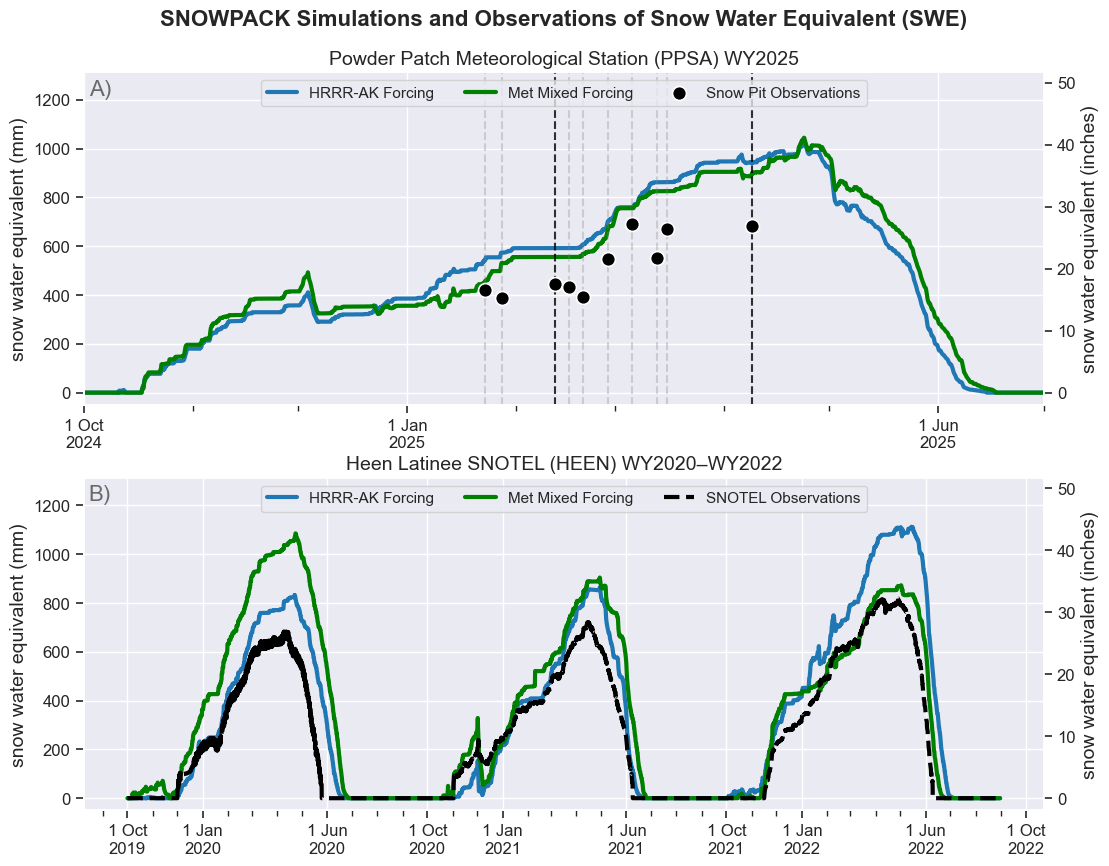

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd


# ============================================================
# FIGURE 4
# SNOWPACK Simulations and Observations of SWE
#
# A) PPSA SWE, WY2025
# B) HEEN SWE, WY2020-WY2022
# ============================================================


# ============================================================
# MANUSCRIPT FORMATTING
# ============================================================

figure_title_fontsize = 16
panel_title_fontsize = 14
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11
panel_label_fontsize = 16

line_width = 3
scatter_size = 100

major_tick_length = 6
major_tick_width = 1.2

minor_tick_length = 4
minor_tick_width = 1.0


# ============================================================
# DATE RANGES
# ============================================================

# PPSA -> WY2025
ppsa_start = "2024-10-01"
ppsa_end = "2025-07-01"

# HEEN -> WY2020-WY2022
heen_start = "2019-09-01"
heen_end = "2022-08-30"


# ============================================================
# SUBSET PPSA DATA
# ============================================================

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_ppsa_plot = (
    ds_snowpack_met_hrrrak_lapserate_ppsa.sel(
        timestamp=slice(ppsa_start, ppsa_end)
    )
)

# Snow-pit measurements within plotting period
df_field_measurements_plot = df_field_measurements.loc[
    (df_field_measurements.index >= ppsa_start) &
    (df_field_measurements.index <= ppsa_end)
]


# ============================================================
# SUBSET HEEN DATA
# ============================================================

# Observations
ds_obs_heen_plot = ds_obs_heen.sel(
    time=slice(heen_start, heen_end)
)

# HRRR-AK lapse-rate corrected
ds_snowpack_hrrrak_lapserate_heen_plot = (
    ds_snowpack_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)

# Met Mixed + lapse-rate corrected HRRR-AK
ds_snowpack_met_hrrrak_lapserate_heen_plot = (
    ds_snowpack_met_hrrrak_lapserate_heen.sel(
        timestamp=slice(heen_start, heen_end)
    )
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 9),
    sharey=True
)

plt.subplots_adjust(
    hspace=0.18
)


# ============================================================
# A) PPSA SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax1,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.plot(
    ax=ax1,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Snow-pit dates
# Highlight Feb 12 and Apr 9 in black; keep all others grey
highlight_dates = [
    pd.Timestamp("2025-02-12"),
    pd.Timestamp("2025-04-09"),
]

for date in df_field_measurements_plot.index:

    if date.normalize() in highlight_dates:
        line_color = "black"
        line_alpha = 0.8
    else:
        line_color = "grey"
        line_alpha = 0.3

    ax1.axvline(
        x=date,
        color=line_color,
        linestyle="--",
        alpha=line_alpha
    )

# Observed SWE from snow pits
ax1.scatter(
    df_field_measurements_plot.index,
    df_field_measurements_plot["swe_mm"],
    color="black",
    edgecolors="white",
    linewidths=1.2,
    s=scatter_size,
    zorder=3,
    label="Snow Pit Observations"
)


# ------------------------------------------------------------
# Panel A formatting
# ------------------------------------------------------------

ax1.set_title(
    "Powder Patch Meteorological Station (PPSA) WY2025",
    fontsize=panel_title_fontsize
)

ax1.set_ylabel(
    "snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax1.set_xlabel("")

ax1.set_xlim(
    mdates.datestr2num(ppsa_start),
    mdates.datestr2num(ppsa_end)
)

ax1.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1.legend(
    loc="upper center",
    fontsize=legend_fontsize,
    frameon=True,
    ncol=3
)

# Panel label
ax1.text(
    0.005, 0.98,
    "A)",
    transform=ax1.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel A secondary y-axis: inches
# ------------------------------------------------------------

ax1_twin = ax1.twinx()

ax1_twin.set_ylabel(
    "snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax1_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax1_twin.grid(False)


# ============================================================
# B) HEEN SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax2,
    label="HRRR-AK Forcing",
    linewidth=line_width,
    color="tab:blue"
)

# Met Mixed forcing
ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.plot(
    ax=ax2,
    label="Met Mixed Forcing",
    linewidth=line_width,
    color="green"
)

# Continuous HEEN SWE observations
# Convert observed SWE to mm
(ds_obs_heen_plot.swe * 10).plot(
    ax=ax2,
    label="SNOTEL Observations",
    linewidth=line_width,
    linestyle="--",
    color="black"
)


# ------------------------------------------------------------
# Panel B formatting
# ------------------------------------------------------------

ax2.set_title(
    "Heen Latinee SNOTEL (HEEN) WY2020–WY2022",
    fontsize=panel_title_fontsize
)

ax2.set_ylabel(
    "snow water equivalent (mm)",
    fontsize=axis_label_fontsize
)

ax2.set_xlabel("")

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2.legend(
    loc="upper center",
    fontsize=legend_fontsize,
    frameon=True,
    ncol=3
)

# Panel label
ax2.text(
    0.005, 0.98,
    "B)",
    transform=ax2.transAxes,
    fontsize=panel_label_fontsize,
    color="dimgrey",
    va="top"
)


# ------------------------------------------------------------
# Panel B secondary y-axis: inches
# ------------------------------------------------------------

ax2_twin = ax2.twinx()

ax2_twin.set_ylabel(
    "snow water equivalent (inches)",
    fontsize=axis_label_fontsize
)

ax2_twin.tick_params(
    axis="y",
    which="major",
    labelsize=tick_fontsize,
    length=major_tick_length,
    width=major_tick_width
)

ax2_twin.grid(False)


# ============================================================
# SYNCHRONIZE SWE Y-AXES
# ============================================================

swe_max = max(
    float(ds_snowpack_hrrrak_lapserate_ppsa_plot.SWE.max()),
    float(ds_snowpack_met_hrrrak_lapserate_ppsa_plot.SWE.max()),
    float(df_field_measurements_plot["swe_mm"].max()),
    float(ds_snowpack_hrrrak_lapserate_heen_plot.SWE.max()),
    float(ds_snowpack_met_hrrrak_lapserate_heen_plot.SWE.max()),
    float((ds_obs_heen_plot.swe * 10).max())
)

swe_ymin = -50
swe_ymax = swe_max + 200

ax1.set_ylim(
    swe_ymin,
    swe_ymax
)

# ax2 automatically shares the same limits because sharey=True


# ------------------------------------------------------------
# Synchronize secondary SWE axes in inches
# ------------------------------------------------------------

ax1_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)

ax2_twin.set_ylim(
    swe_ymin * 0.0393701,
    swe_ymax * 0.0393701
)


# ============================================================
# X-AXIS FORMATTING
# ============================================================

for ax in [ax1, ax2]:

    # Major ticks:
    # Label only October 1, January 1, and June 1
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(bymonth=[10, 1, 6], bymonthday=1)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%-d %b\n%Y")
    )

    # Minor ticks:
    # Add an unlabeled tick on the first day of every month
    ax.xaxis.set_minor_locator(
        mdates.MonthLocator(bymonthday=1)
    )

    # Major tick formatting
    ax.tick_params(
        axis="x",
        which="major",
        bottom=True,
        labelbottom=True,
        labelsize=tick_fontsize,
        length=major_tick_length,
        width=major_tick_width
    )

    # Minor monthly tick formatting
    ax.tick_params(
        axis="x",
        which="minor",
        bottom=True,
        labelbottom=False,
        length=minor_tick_length,
        width=minor_tick_width
    )


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "SNOWPACK Simulations and Observations of "
    "Snow Water Equivalent (SWE)",
    fontsize=figure_title_fontsize,
    fontweight="bold",
    y=0.97
)


# ============================================================
# FINAL LAYOUT
# ============================================================

fig.subplots_adjust(
    top=0.90,
    bottom=0.08,
    left=0.10,
    right=0.90,
    hspace=0.22
)


# ============================================================
# SAVE FIGURE
# ============================================================

# High-resolution PNG
plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure5.png",
    dpi=300,
    bbox_inches="tight"
)

# Vector PDF for journal submission
plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure5.pdf",
    bbox_inches="tight"
)

plt.show()

# Calculations

In [15]:
import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# HEEN SWE EVALUATION
#
# Compare:
#   1. HRRR-AK forcing
#   2. Met Mixed forcing
#
# Final manuscript configurations:
#   lapse-rate corrected HRRR-AK temperature
#
# Period:
#   WY2020-WY2022
# ============================================================


# ============================================================
# SETTINGS
# ============================================================

heen_start = "2019-09-01"
heen_end   = "2022-08-30"

water_years = [2020, 2021, 2022]

# Threshold used to define presence / disappearance of SWE.
# This avoids treating tiny numerical residuals as snow.
swe_threshold_mm = 5.0

# Number of consecutive snow-free days required to define
# disappearance.
disappearance_days = 5


# ============================================================
# PREPARE DAILY SWE SERIES
# ============================================================

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

# HEEN SNOTEL SWE is converted to mm here
obs_swe = (
    ds_obs_heen
    .sel(time=slice(heen_start, heen_end))
    .swe
    * 10
)

obs_swe = obs_swe.to_series()

obs_swe.index = pd.to_datetime(obs_swe.index)

# Convert to daily values
obs_swe_daily = obs_swe.resample("1D").mean()


# ------------------------------------------------------------
# HRRR-AK forcing
# ------------------------------------------------------------

hrrr_swe = (
    ds_snowpack_hrrrak_lapserate_heen
    .sel(timestamp=slice(heen_start, heen_end))
    .SWE
    .to_series()
)

hrrr_swe.index = pd.to_datetime(hrrr_swe.index)

# Convert hourly SNOWPACK output to daily SWE
hrrr_swe_daily = hrrr_swe.resample("1D").mean()


# ------------------------------------------------------------
# Met Mixed forcing
# ------------------------------------------------------------

mixed_swe = (
    ds_snowpack_met_hrrrak_lapserate_heen
    .sel(timestamp=slice(heen_start, heen_end))
    .SWE
    .to_series()
)

mixed_swe.index = pd.to_datetime(mixed_swe.index)

# Convert hourly SNOWPACK output to daily SWE
mixed_swe_daily = mixed_swe.resample("1D").mean()


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_water_year_dates(wy):
    """
    Return start and end dates for a water year.

    Example:
        WY2020 = 1 Oct 2019 through 30 Sep 2020
    """

    start = pd.Timestamp(f"{wy - 1}-10-01")
    end = pd.Timestamp(f"{wy}-09-30")

    return start, end


def find_disappearance_date(
    series,
    peak_date,
    threshold=5.0,
    consecutive_days=5
):
    """
    Find snow disappearance following the seasonal peak.

    Disappearance is defined as the first date after peak SWE
    when SWE remains <= threshold for at least the specified
    number of consecutive days.
    """

    after_peak = series.loc[peak_date:].dropna()

    if len(after_peak) < consecutive_days:
        return pd.NaT

    snow_free = after_peak <= threshold

    # Rolling window requiring all days to be below threshold
    persistent_zero = (
        snow_free
        .rolling(
            window=consecutive_days,
            min_periods=consecutive_days
        )
        .sum()
        == consecutive_days
    )

    if not persistent_zero.any():
        return pd.NaT

    # rolling() marks the END of the window,
    # so move back to the first day of disappearance
    end_date = persistent_zero[persistent_zero].index[0]

    disappearance_date = (
        end_date
        - pd.Timedelta(days=consecutive_days - 1)
    )

    return disappearance_date


def calculate_swe_metrics(
    obs,
    model,
    wy,
    threshold=5.0,
    consecutive_days=5
):
    """
    Calculate SWE evaluation metrics for one water year.
    """

    start, end = get_water_year_dates(wy)

    obs_wy = obs.loc[start:end]
    model_wy = model.loc[start:end]

    # --------------------------------------------------------
    # Align observations and model
    # --------------------------------------------------------

    comparison = pd.concat(
        [
            obs_wy.rename("obs"),
            model_wy.rename("model")
        ],
        axis=1,
        join="inner"
    ).dropna()

    if comparison.empty:
        return None


    # ========================================================
    # Continuous-error metrics
    # ========================================================

    error = comparison["model"] - comparison["obs"]

    rmse = np.sqrt(np.mean(error**2))
    bias = np.mean(error)
    mae = np.mean(np.abs(error))


    # ========================================================
    # Peak SWE
    # ========================================================

    obs_peak_swe = comparison["obs"].max()
    model_peak_swe = comparison["model"].max()

    obs_peak_date = comparison["obs"].idxmax()
    model_peak_date = comparison["model"].idxmax()

    peak_swe_error = model_peak_swe - obs_peak_swe

    peak_date_error_days = (
        model_peak_date - obs_peak_date
    ).days


    # ========================================================
    # Snow disappearance
    # ========================================================

    obs_disappearance = find_disappearance_date(
        comparison["obs"],
        obs_peak_date,
        threshold=threshold,
        consecutive_days=consecutive_days
    )

    model_disappearance = find_disappearance_date(
        comparison["model"],
        model_peak_date,
        threshold=threshold,
        consecutive_days=consecutive_days
    )


    if (
        pd.notna(obs_disappearance)
        and pd.notna(model_disappearance)
    ):

        disappearance_error_days = (
            model_disappearance
            - obs_disappearance
        ).days

    else:
        disappearance_error_days = np.nan


    # ========================================================
    # Melt duration
    #
    # Peak SWE -> disappearance
    # ========================================================

    if pd.notna(obs_disappearance):

        obs_melt_duration = (
            obs_disappearance - obs_peak_date
        ).days

    else:

        obs_melt_duration = np.nan


    if pd.notna(model_disappearance):

        model_melt_duration = (
            model_disappearance - model_peak_date
        ).days

    else:

        model_melt_duration = np.nan


    if (
        not np.isnan(obs_melt_duration)
        and not np.isnan(model_melt_duration)
    ):

        melt_duration_error = (
            model_melt_duration
            - obs_melt_duration
        )

    else:

        melt_duration_error = np.nan


    # ========================================================
    # Return metrics
    # ========================================================

    return {

        "WY": wy,

        "RMSE_mm": rmse,
        "Bias_mm": bias,
        "MAE_mm": mae,

        "Obs_Peak_SWE_mm": obs_peak_swe,
        "Model_Peak_SWE_mm": model_peak_swe,
        "Peak_SWE_Error_mm": peak_swe_error,

        "Obs_Peak_Date": obs_peak_date,
        "Model_Peak_Date": model_peak_date,
        "Peak_Date_Error_days": peak_date_error_days,

        "Obs_Disappearance_Date": obs_disappearance,
        "Model_Disappearance_Date": model_disappearance,
        "Disappearance_Error_days": disappearance_error_days,

        "Obs_Melt_Duration_days": obs_melt_duration,
        "Model_Melt_Duration_days": model_melt_duration,
        "Melt_Duration_Error_days": melt_duration_error,

        "N_days": len(comparison)
    }


# ============================================================
# CALCULATE METRICS BY WATER YEAR
# ============================================================

results = []


# ------------------------------------------------------------
# HRRR-AK
# ------------------------------------------------------------

for wy in water_years:

    metrics = calculate_swe_metrics(
        obs=obs_swe_daily,
        model=hrrr_swe_daily,
        wy=wy,
        threshold=swe_threshold_mm,
        consecutive_days=disappearance_days
    )

    if metrics is not None:

        metrics["Forcing"] = "HRRR-AK"

        results.append(metrics)


# ------------------------------------------------------------
# Met Mixed
# ------------------------------------------------------------

for wy in water_years:

    metrics = calculate_swe_metrics(
        obs=obs_swe_daily,
        model=mixed_swe_daily,
        wy=wy,
        threshold=swe_threshold_mm,
        consecutive_days=disappearance_days
    )

    if metrics is not None:

        metrics["Forcing"] = "Met Mixed"

        results.append(metrics)


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

df_heen_swe_metrics = pd.DataFrame(results)

# Put identifying columns first
column_order = [

    "Forcing",
    "WY",

    "RMSE_mm",
    "Bias_mm",
    "MAE_mm",

    "Obs_Peak_SWE_mm",
    "Model_Peak_SWE_mm",
    "Peak_SWE_Error_mm",

    "Obs_Peak_Date",
    "Model_Peak_Date",
    "Peak_Date_Error_days",

    "Obs_Disappearance_Date",
    "Model_Disappearance_Date",
    "Disappearance_Error_days",

    "Obs_Melt_Duration_days",
    "Model_Melt_Duration_days",
    "Melt_Duration_Error_days",

    "N_days"
]

df_heen_swe_metrics = df_heen_swe_metrics[column_order]


# ============================================================
# ROUND NUMERIC VALUES FOR DISPLAY
# ============================================================

display_columns = [
    "RMSE_mm",
    "Bias_mm",
    "MAE_mm",
    "Obs_Peak_SWE_mm",
    "Model_Peak_SWE_mm",
    "Peak_SWE_Error_mm"
]

df_heen_swe_metrics[display_columns] = (
    df_heen_swe_metrics[display_columns].round(1)
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\nHEEN SWE metrics by water year:\n")

print(
    df_heen_swe_metrics.to_string(index=False)
)


HEEN SWE metrics by water year:

  Forcing   WY  RMSE_mm  Bias_mm  MAE_mm  Obs_Peak_SWE_mm  Model_Peak_SWE_mm  Peak_SWE_Error_mm Obs_Peak_Date Model_Peak_Date  Peak_Date_Error_days Obs_Disappearance_Date Model_Disappearance_Date  Disappearance_Error_days  Obs_Melt_Duration_days  Model_Melt_Duration_days  Melt_Duration_Error_days  N_days
  HRRR-AK 2020    113.1     58.5    63.1            682.0              829.2              147.2    2020-04-09      2020-04-22                    13             2020-05-25               2020-06-20                        26                      46                        59                        13     366
  HRRR-AK 2021     81.1     23.8    53.2            718.9              859.5              140.6    2021-04-14      2021-04-29                    15             2021-06-09               2021-06-20                        11                      56                        52                        -4     365
  HRRR-AK 2022    204.3    144.6   144.6        